In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count()))

import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.preprocessing import load_and_clean, time_split, TARGET
from src.features import add_features

df = add_features(load_and_clean())
train, val, test = time_split(df)
X = lambda d: d.drop(columns=["Date", TARGET])

results = pd.read_csv("reports/model_comparison.csv")
best_name = results.iloc[0]["Model"]
model = joblib.load(f"models/{best_name}.joblib")
print("Best model:", best_name)

Best model: LogisticRegression


In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score

p_val = model.predict_proba(X(val))[:, 1]
y_val = val[TARGET]

rows = []
for t in [0.5, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99]:
    pred = (p_val >= t).astype(int)
    rows.append({"Threshold": t,
                 "Warnings given": pred.sum(),
                 "Storms caught": (pred & y_val).sum(),
                 "Total storms": y_val.sum(),
                 "Precision": round(precision_score(y_val, pred, zero_division=0), 3),
                 "Recall": round(recall_score(y_val, pred), 3),
                 "F1": round(f1_score(y_val, pred), 3)})
pd.DataFrame(rows)

,Threshold,Warnings given,Storms caught,Total storms,Precision,Recall,F1
0,0.50,1550,53,58,0.034,0.914,0.066
1,0.70,1065,50,58,0.047,0.862,0.089
2,0.80,811,46,58,0.057,0.793,0.106
3,0.90,539,44,58,0.082,0.759,0.147
4,0.95,353,42,58,0.119,0.724,0.204
5,0.98,205,34,58,0.166,0.586,0.259
6,0.99,106,28,58,0.264,0.483,0.341


Best threshold: 0.995
At this threshold → Precision 0.373, Recall 0.431, F1 0.400


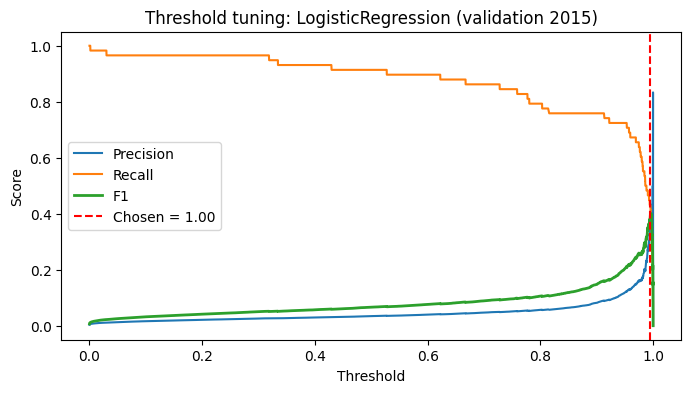

In [3]:
from sklearn.metrics import precision_recall_curve

prec, rec, ths = precision_recall_curve(y_val, p_val)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = np.argmax(f1s[:-1])
threshold = float(ths[best_i])

print(f"Best threshold: {threshold:.3f}")
print(f"At this threshold → Precision {prec[best_i]:.3f}, Recall {rec[best_i]:.3f}, F1 {f1s[best_i]:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(ths, prec[:-1], label="Precision")
plt.plot(ths, rec[:-1], label="Recall")
plt.plot(ths, f1s[:-1], label="F1", linewidth=2)
plt.axvline(threshold, color="red", linestyle="--", label=f"Chosen = {threshold:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title(f"Threshold tuning: {best_name} (validation 2015)")
plt.legend()
plt.savefig("reports/12_threshold_tuning.png", bbox_inches="tight")
plt.show()

FINAL TEST RESULTS (2016–2017)
ROC-AUC: 0.936
PR-AUC:  0.179
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     25847
  Heavy rain       0.23      0.21      0.22        86

    accuracy                           1.00     25933
   macro avg       0.61      0.60      0.61     25933
weighted avg       0.99      1.00      0.99     25933



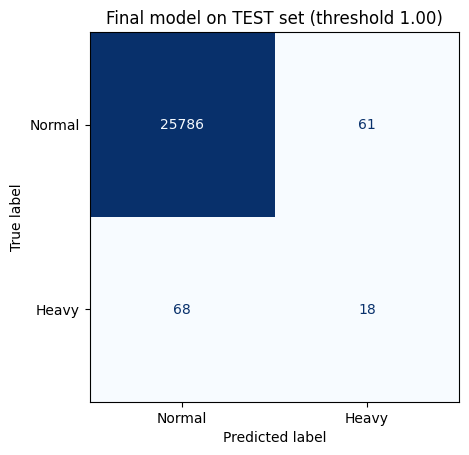

In [4]:
from sklearn.base import clone
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay)

train_val = pd.concat([train, val])
final_model = clone(model).fit(X(train_val), train_val[TARGET])

y_test = test[TARGET]
p_test = final_model.predict_proba(X(test))[:, 1]
pred_test = (p_test >= threshold).astype(int)

print("FINAL TEST RESULTS (2016–2017)")
print("ROC-AUC:", round(roc_auc_score(y_test, p_test), 3))
print("PR-AUC: ", round(average_precision_score(y_test, p_test), 3))
print(classification_report(y_test, pred_test, target_names=["Normal", "Heavy rain"]))

ConfusionMatrixDisplay.from_predictions(y_test, pred_test,
    display_labels=["Normal", "Heavy"], cmap="Blues", colorbar=False)
plt.title(f"Final model on TEST set (threshold {threshold:.2f})")
plt.savefig("reports/13_final_test_confusion.png", bbox_inches="tight")
plt.show()

In [5]:
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/final_model.joblib")

meta = {
    "model": best_name,
    "threshold": threshold,
    "threshold_mm": 64.5,
    "locations": sorted(df["Location"].unique().tolist()),
    "test_roc_auc": round(roc_auc_score(y_test, p_test), 3),
    "test_pr_auc": round(average_precision_score(y_test, p_test), 3),
}
with open("models/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved final_model.joblib and meta.json ✅")
print(json.dumps({k: v for k, v in meta.items() if k != "locations"}, indent=2))

Saved final_model.joblib and meta.json ✅
{
  "model": "LogisticRegression",
  "threshold": 0.9951580487416237,
  "threshold_mm": 64.5,
  "test_roc_auc": 0.936,
  "test_pr_auc": 0.179
}
